# 个人信用违约预测与评分卡模型

基于 15 万条公开个人信贷记录（Kaggle *Give Me Some Credit*），完成从数据清洗、单调 WOE 分箱、IV/共线性筛选，到逻辑回归评分卡、交叉验证、XGBoost 效果参照、评分卡单调性验证与阈值业务分析的完整风控建模流程。

**模型选型：** 主模型用逻辑回归而非 XGBoost——银行风控受监管要求，每一分扣在哪里都必须可解释；XGBoost 仅作为效果上限参照。

In [1]:
%matplotlib inline
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, r'C:/Users/86186/Desktop/portfolio/credit_scoring')
import credit_scoring as cs   # 复用 .py 中的清洗/分箱/评分卡函数，保证脚本与 notebook 同源一致
pd.set_option('display.width', 200)

## 1. 数据清洗

- 删除逻辑异常：年龄 ≤ 0、循环贷使用率 > 13、负债率 > 50；
- **剔除该数据集著名的编码脏值 96/98**：三个逾期次数字段出现 96、98（现实不可能逾期近百次），且为同一批记录三字段同时异常，属损坏数据；
- 月收入、抚养人数缺失用中位数填补；月收入按 99 分位截尾，压制 300 万这类脏值。

In [2]:
df = cs.load_and_clean()
print('清洗后形状:', df.shape)
print('违约率: %.4f' % df[cs.TARGET].mean())

[清洗] 剔除逾期次数脏值(96/98 编码错误)记录 260 条
[清洗] 样本量=123,584  违约率=0.0679
[清洗] 月收入 99 分位截尾值=25,000
清洗后形状: (123584, 11)
违约率: 0.0679


## 2. 关键排查：三个逾期变量的「伪共线」

三个逾期次数变量（30-59 天 / 60-89 天 / 90 天以上）在**原始数据**上两两相关系数高达 0.98，看似严重多重共线、不能同时入模。进一步排查发现：这正是 96/98 脏值造成的假象——同一条损坏记录的三个字段被同时写成 98，这些远离主体的极端杠杆点把皮尔逊相关系数人为抬高。**剔除脏值后相关系数降到 0.2~0.3**，说明它们刻画的是不同逾期阶段，可以同时入模。这也是必须先做数据质量排查、再谈特征筛选的原因。

In [3]:
raw = pd.read_csv(cs.DATA_FILE, index_col=0)
overdue = ['NumberOfTime30-59DaysPastDueNotWorse',
           'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse']
print('清洗前（含 96/98 脏值）相关系数：')
print(raw[overdue].corr().round(3))
print('\n清洗后相关系数：')
print(df[overdue].corr().round(3))

清洗前（含 96/98 脏值）相关系数：
                                      NumberOfTime30-59DaysPastDueNotWorse  NumberOfTimes90DaysLate  NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse                                 1.000                    0.984                                 0.987
NumberOfTimes90DaysLate                                              0.984                    1.000                                 0.993
NumberOfTime60-89DaysPastDueNotWorse                                 0.987                    0.993                                 1.000

清洗后相关系数：
                                      NumberOfTime30-59DaysPastDueNotWorse  NumberOfTimes90DaysLate  NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse                                 1.000                    0.217                                 0.304
NumberOfTimes90DaysLate                                              0.217                    1.000                                 0.290
Num

## 3. 单调 WOE 分箱与 IV

- 连续变量等频初箱、有序离散变量（逾期次数等）按取值分箱，再用贪心相邻合并强制 **WOE 单调**（评分卡最重要的约束）；
- IV 衡量单变量区分能力，行业经验阈值 IV > 0.02 入模。

In [4]:
feature_cols = [c for c in df.columns if c != cs.TARGET]
bin_meta = {}
rows = []
for col in feature_cols:
    binspec, woe_map, iv, detail, mono = cs.woe_binning(df, col, len(df))
    bin_meta[col] = {'binspec': binspec, 'woe_map': woe_map, 'iv': iv,
                     'detail': detail, 'monotonic': mono}
    rows.append((col, round(iv, 4), len(detail), mono))
iv_df = pd.DataFrame(rows, columns=['变量', 'IV', '箱数', 'WOE单调']).sort_values('IV', ascending=False)
iv_df.reset_index(drop=True)

,变量,IV,箱数,WOE单调
0,RevolvingUtilizationOfUnsecuredLines,1.0193,8,True
1,NumberOfTimes90DaysLate,0.8018,3,True
2,NumberOfTime30-59DaysPastDueNotWorse,0.6844,3,True
3,NumberOfTime60-89DaysPastDueNotWorse,0.5341,3,True
4,age,0.2342,10,True
5,MonthlyIncome,0.0809,8,True
6,DebtRatio,0.0601,5,True
7,NumberOfDependents,0.0408,4,True
8,NumberRealEstateLoansOrLines,0.0117,3,False
9,NumberOfOpenCreditLinesAndLoans,0.0004,3,False


## 4. IV 筛选 + 共线性筛选

先按 IV > 0.02 初筛，再按 IV 从高到低贪心保留：与已保留变量 |相关系数| > 0.8 的剔除（评分卡要求入模变量相对独立）。本数据中该防线通过、未再剔除变量（伪共线已在清洗环节解决）。

In [5]:
iv_pass = [c for c in feature_cols if bin_meta[c]['iv'] > 0.02]
selected = []
for c in sorted(iv_pass, key=lambda x: -bin_meta[x]['iv']):
    if not selected:
        selected.append(c); continue
    corrs = [abs(df[c].corr(df[s])) for s in selected]
    m = max(corrs)
    if m > 0.8:
        print('剔除 %s（与 %s 相关 %.3f）' % (c, selected[int(np.argmax(corrs))], m))
    else:
        selected.append(c)
print('IV 初筛 %d 个，最终入模 %d 个：' % (len(iv_pass), len(selected)))
for c in selected:
    print('  -', c, ' IV=%.4f' % bin_meta[c]['iv'])

IV 初筛 8 个，最终入模 8 个：
  - RevolvingUtilizationOfUnsecuredLines  IV=1.0193
  - NumberOfTimes90DaysLate  IV=0.8018
  - NumberOfTime30-59DaysPastDueNotWorse  IV=0.6844
  - NumberOfTime60-89DaysPastDueNotWorse  IV=0.5341
  - age  IV=0.2342
  - MonthlyIncome  IV=0.0809
  - DebtRatio  IV=0.0601
  - NumberOfDependents  IV=0.0408


## 5. 训练/测试切分与 WOE 特征矩阵

分层切分 7:3；用同一套分箱边界把原始值映射为 WOE，作为逻辑回归输入。

In [6]:
from sklearn.model_selection import train_test_split
X, y = df.drop(columns=[cs.TARGET]), df[cs.TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=cs.RANDOM_STATE)

def build_woe(data):
    return np.column_stack([cs.apply_woe(data, c, bin_meta[c]['binspec'],
                                         bin_meta[c]['woe_map']) for c in selected])
Xtr_w, Xte_w = build_woe(X_train), build_woe(X_test)
print('训练:', Xtr_w.shape, ' 测试:', Xte_w.shape)

训练: (86508, 8)  测试: (37076, 8)


## 6. 5 折交叉验证 + 逻辑回归 + XGBoost 效果参照

5 折分层交叉验证看稳定性；逻辑回归为主模型，XGBoost 仅作效果上限参照。

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=cs.RANDOM_STATE)
cv_auc, cv_ks = [], []
for tr, va in skf.split(Xtr_w, y_train):
    m_ = LogisticRegression(max_iter=1000, random_state=cs.RANDOM_STATE).fit(Xtr_w[tr], y_train.iloc[tr])
    p_ = m_.predict_proba(Xtr_w[va])[:, 1]
    f_, t_, _ = roc_curve(y_train.iloc[va], p_)
    cv_auc.append(roc_auc_score(y_train.iloc[va], p_)); cv_ks.append(np.max(t_ - f_))
print('5 折 CV  AUC: %.4f ± %.4f   KS: %.4f ± %.4f' % (np.mean(cv_auc), np.std(cv_auc), np.mean(cv_ks), np.std(cv_ks)))

lr = LogisticRegression(max_iter=1000, random_state=cs.RANDOM_STATE).fit(Xtr_w, y_train)
proba_tr = lr.predict_proba(Xtr_w)[:, 1]
proba_te = lr.predict_proba(Xte_w)[:, 1]
fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_tr)
fpr_te, tpr_te, _ = roc_curve(y_test, proba_te)
print('逻辑回归 测试集 AUC=%.4f  KS=%.4f' % (roc_auc_score(y_test, proba_te), np.max(tpr_te - fpr_te)))

from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                    colsample_bytree=0.8, eval_metric='auc', random_state=cs.RANDOM_STATE, verbosity=0)
xgb.fit(Xtr_w, y_train)
proba_xgb = xgb.predict_proba(Xte_w)[:, 1]
fpr_x, tpr_x, _ = roc_curve(y_test, proba_xgb)
print('XGBoost  测试集 AUC=%.4f（效果上限参照）' % roc_auc_score(y_test, proba_xgb))

5 折 CV  AUC: 0.8430 ± 0.0064   KS: 0.5372 ± 0.0120
逻辑回归 测试集 AUC=0.8468  KS=0.5367


XGBoost  测试集 AUC=0.8555（效果上限参照）


## 7. bootstrap 稳定性

数据无申请时间字段，无法做严格的跨时间 OOT 验证，这里用 200 次 bootstrap 重采样估计测试集 AUC 的 95% 置信区间，作为稳定性的近似（该局限如实说明）。

In [8]:
rng = np.random.default_rng(cs.RANDOM_STATE)
boot = []
idx_all = np.arange(len(y_test))
for _ in range(200):
    idx = rng.choice(idx_all, len(y_test), replace=True)
    if len(np.unique(y_test.iloc[idx])) < 2: continue
    boot.append(roc_auc_score(y_test.iloc[idx], proba_te[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print('测试集 AUC 的 bootstrap 95%% 置信区间: [%.4f, %.4f]' % (lo, hi))

测试集 AUC 的 bootstrap 95% 置信区间: [0.8385, 0.8555]


## 8. ROC 对比：逻辑回归 vs XGBoost

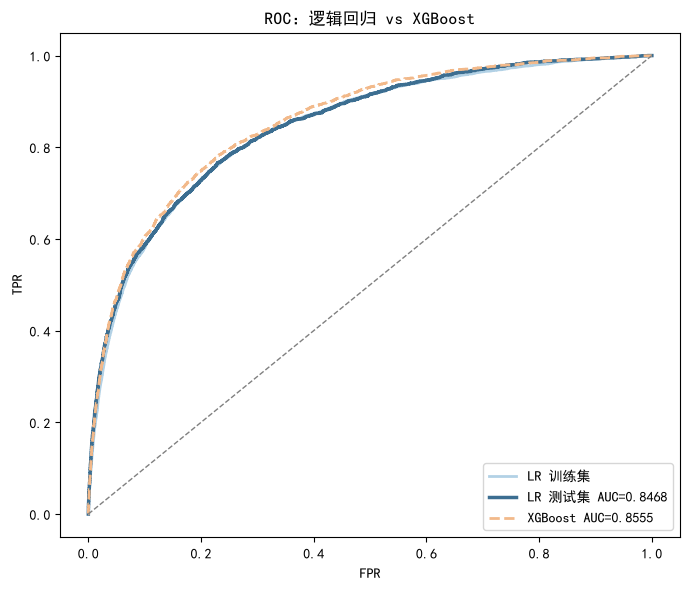

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_tr, tpr_tr, color='#7FB3D5', lw=2, alpha=0.6, label='LR 训练集')
ax.plot(fpr_te, tpr_te, color='#3C6E91', lw=2.5, label='LR 测试集 AUC=%.4f' % roc_auc_score(y_test, proba_te))
ax.plot(fpr_x, tpr_x, color='#F2B98A', lw=2, ls='--', label='XGBoost AUC=%.4f' % roc_auc_score(y_test, proba_xgb))
ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC：逻辑回归 vs XGBoost'); ax.legend(loc='lower right')
fig.tight_layout(); fig

## 9. 评分卡转换

基准分 600、PDO=50（odds 每翻倍扣 50 分），把逻辑回归系数 × WOE 转成每个分箱的加减分值，得到业务可读、可解释的标准评分卡。

In [10]:
coef_dict = dict(zip(selected, lr.coef_[0]))
intercept = float(lr.intercept_[0])
odds_base = y_train.mean() / (1 - y_train.mean())
offset = cs.BASE_SCORE - cs.FACTOR * np.log(odds_base)

cards = []
for col in selected:
    d = bin_meta[col]['detail'].copy(); d['variable'] = col
    d['points'] = (-cs.FACTOR * coef_dict[col] * d['woe']).round(0).astype(int)
    cards.append(d[['variable', '_b', 'count', 'bad_rate', 'woe', 'points']])
scorecard = pd.concat(cards, ignore_index=True)
scorecard.head(12)

,variable,_b,count,bad_rate,woe,points
0,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.00329]|(0.00329, 0.0196]|(0.0196, 0...",37075,0.018260,-1.364738,67
1,RevolvingUtilizationOfUnsecuredLines,"(0.0447, 0.088]",12359,0.021442,-1.199756,59
2,RevolvingUtilizationOfUnsecuredLines,"(0.088, 0.164]",12358,0.027513,-0.944652,47
3,RevolvingUtilizationOfUnsecuredLines,"(0.164, 0.286]",12358,0.036737,-0.646339,32
4,RevolvingUtilizationOfUnsecuredLines,"(0.286, 0.459]",12359,0.056153,-0.202064,10
5,RevolvingUtilizationOfUnsecuredLines,"(0.459, 0.704]",12358,0.090710,0.314546,-15
6,RevolvingUtilizationOfUnsecuredLines,"(0.704, 0.975]",12358,0.163619,0.987788,-49
7,RevolvingUtilizationOfUnsecuredLines,"(0.975, 12.463]",12359,0.227931,1.399230,-69
8,NumberOfTimes90DaysLate,0,116840,0.048194,-0.363629,14
9,NumberOfTimes90DaysLate,1,4430,0.336795,1.941965,-76


## 10. 评分卡单调性验证

把测试集客户按得分十等分，看每段的实际违约率——**分数越高、违约率必须单调下降**，这是评分卡可用的前提。

In [11]:
def score_of(Xw):
    s = np.full(len(Xw), offset + cs.FACTOR * intercept)
    for j, c in enumerate(selected):
        s += -cs.FACTOR * coef_dict[c] * Xw[:, j]
    return s
score_te = score_of(Xte_w)
tmp = pd.DataFrame({'score': score_te, 'y': y_test.values})
bucket = pd.qcut(pd.Series(score_te), 10, duplicates='drop')
mono = tmp.assign(bucket=bucket).groupby('bucket', observed=True).agg(
    平均分=('score', 'mean'), 违约率=('y', 'mean'), 样本量=('y', 'size')).reset_index(drop=True)
mono

,平均分,违约率,样本量
0,459.278980,0.357875,3708
1,563.521342,0.107854,3718
2,598.174484,0.073012,3698
3,626.612893,0.045050,3707
4,647.534274,0.028841,3710
5,666.833055,0.025371,3705
6,684.486945,0.018339,3708
7,701.566087,0.012675,3708
8,719.736179,0.004585,3708
9,744.828942,0.005127,3706


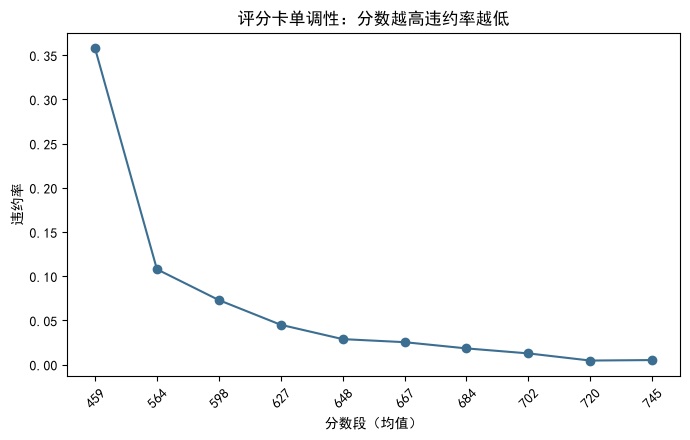

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(len(mono)), mono['违约率'], marker='o', color='#3C6E91')
ax.set_xticks(range(len(mono)))
ax.set_xticklabels(['%.0f' % v for v in mono['平均分']], rotation=45)
ax.set_xlabel('分数段（均值）'); ax.set_ylabel('违约率'); ax.set_title('评分卡单调性：分数越高违约率越低')
fig.tight_layout(); fig

## 11. 阈值与业务成本分析

风控不是只看 AUC：定多少分通过、多少分拒绝，取决于「拒绝率」与「被拒客户坏账率」之间的业务权衡。

In [13]:
rows = []
for t in np.percentile(score_te, [70, 60, 50, 40, 30, 20]):
    rej = score_te < t
    rows.append((round(t, 1), round(rej.mean(), 3), round(y_test.values[rej].mean(), 4)))
th = pd.DataFrame(rows, columns=['分数阈值', '拒绝率', '被拒客户坏账率'])
th

,分数阈值,拒绝率,被拒客户坏账率
0,692.9,0.7,0.0938
1,676.1,0.6,0.1064
2,656.6,0.5,0.1226
3,638.1,0.4,0.1460
4,613.7,0.3,0.1797
5,581.5,0.2,0.2330


## 12. 结论

1. **数据质量是风控建模的前提**：三个逾期变量的「伪共线」由 96/98 脏值造成，清洗后才是真实关系；逾期次数（尤其 90 天以上）与循环贷使用率是最强风险信号。
2. **可解释模型效果并不逊色**：逻辑回归测试集 AUC/KS 与 XGBoost 上限参照非常接近，但每一分都可归因，满足监管可解释要求。
3. **评分卡业务可用**：分数段违约率严格单调下降；结合阈值表，可在「获客规模」与「坏账损失」之间做量化权衡。
4. **如实交代局限**：数据无时间字段，无法做跨时间 OOT 与 PSI 漂移监控，以 bootstrap 近似稳定性，后续可补时间维度样本。